# Exploración visual del dataset Chákṣu

Este notebook analiza las características visuales y técnicas de las
retinografías del dataset Chákṣu antes de definir el pipeline de
preprocesamiento.

Objetivos:

1. Verificar que las imágenes puedan ser decodificadas correctamente.
2. Analizar las dimensiones y relaciones de aspecto originales.
3. Verificar el número de canales.
4. Comparar características entre los dispositivos Bosch, Forus y Remidio.
5. Inspeccionar visualmente ejemplos de las clases NORMAL y GLAUCOMA SUSPECT.
6. Evaluar la presencia de bordes negros y características del campo de visión.
7. Obtener evidencia para definir posteriormente el resize, recorte,
   normalización y Data Augmentation.

En esta etapa no se modifican las imágenes originales.

## 1. Importaciones

Importación de librerías para manejo de rutas de archivos, análisis tabular de metadatos y visualización de imágenes mediante PIL y Matplotlib.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

## 2. Configuración

Definición de las rutas del proyecto y comprobación de la existencia del archivo de particiones congeladas `chaksu_splits.csv`.

In [2]:
PROJECT_ROOT = Path(r"C:\Users\SeuNg720\Documents\TP1-RetiScan")
CHAKSU_ROOT = (
    PROJECT_ROOT
    / "datasets"
    / "glaucoma"
    / "chaksu"
)
METADATA_DIR = CHAKSU_ROOT / "metadata"
SPLITS_PATH = (
    METADATA_DIR
    / "chaksu_splits.csv"
)
print("Metadata existe:", SPLITS_PATH.exists())

Metadata existe: True


## 3. Cargar las particiones congeladas

Carga de las particiones preparadas en el notebook 02, confirmando que se preservan exactamente los tamaños de Train (807), Validation (202) y Test (336).

In [3]:
df = pd.read_csv(SPLITS_PATH)
print("Filas:", len(df))
display(df.head())

print(
    df["experimental_split"]
    .value_counts()
)

Filas: 1345


,image_key,image_name,image_path,camera,original_label,functional_label,label,official_split,experimental_split
0,remidio::img_3244.jpg,IMG_3244.JPG,datasets/glaucoma/chaksu/raw/Train/1.0_Origina...,Remidio,NORMAL,LOW_RISK,0,train,train
1,remidio::img_3503.jpg,IMG_3503.JPG,datasets/glaucoma/chaksu/raw/Train/1.0_Origina...,Remidio,NORMAL,LOW_RISK,0,train,train
2,remidio::img_3263.jpg,IMG_3263.JPG,datasets/glaucoma/chaksu/raw/Train/1.0_Origina...,Remidio,NORMAL,LOW_RISK,0,train,train
3,remidio::img_3389.jpg,IMG_3389.JPG,datasets/glaucoma/chaksu/raw/Train/1.0_Origina...,Remidio,NORMAL,LOW_RISK,0,train,train
4,remidio::img_3349.jpg,IMG_3349.JPG,datasets/glaucoma/chaksu/raw/Train/1.0_Origina...,Remidio,NORMAL,LOW_RISK,0,train,train


experimental_split
train         807
test          336
validation    202
Name: count, dtype: int64


## 4. Verificar que todas las imágenes siguen existiendo

Resolución de las rutas relativas contra `PROJECT_ROOT` y verificación de que ningún archivo físico se haya extraviado o renombrado.

In [4]:
def resolver_ruta(ruta_relativa):
    return PROJECT_ROOT / Path(ruta_relativa)

df["path_exists"] = (
    df["image_path"]
    .apply(
        lambda ruta:
        resolver_ruta(ruta).exists()
    )
)
print(
    "Imágenes localizadas:",
    df["path_exists"].sum()
)
print(
    "Imágenes no localizadas:",
    (~df["path_exists"]).sum()
)

Imágenes localizadas: 1345
Imágenes no localizadas: 0


## 5. Inspeccionar dimensiones, canales y formato

Apertura liviana de los encabezados de las 1,345 imágenes para extraer ancho, alto, modo de color y formato, verificando que no existan archivos corruptos o ilegibles.

In [5]:
registros_imagen = []
for _, fila in df.iterrows():
    ruta = resolver_ruta(
        fila["image_path"]
    )
    try:
        with Image.open(ruta) as img:
            registros_imagen.append({
                "image_key": fila["image_key"],
                "camera": fila["camera"],
                "original_label": fila["original_label"],
                "experimental_split": fila["experimental_split"],
                "width": img.width,
                "height": img.height,
                "mode": img.mode,
                "format": img.format,
                "error": None
            })
    except Exception as e:
        registros_imagen.append({
            "image_key": fila["image_key"],
            "camera": fila["camera"],
            "original_label": fila["original_label"],
            "experimental_split": fila["experimental_split"],
            "width": None,
            "height": None,
            "mode": None,
            "format": None,
            "error": str(e)
        })

image_info = pd.DataFrame(
    registros_imagen
)
print("Imágenes analizadas:", len(image_info))
print(
    "Errores de lectura:",
    image_info["error"]
    .notna()
    .sum()
)

Imágenes analizadas: 1345
Errores de lectura: 0


## 6. Revisar resoluciones

Tabla de resoluciones nativas agrupadas por dispositivo de adquisición para identificar la heterogeneidad dimensional del dataset.

In [6]:
resoluciones = (
    image_info
    .groupby(
        [
            "camera",
            "width",
            "height"
        ]
    )
    .size()
    .reset_index(
        name="cantidad"
    )
    .sort_values(
        [
            "camera",
            "cantidad"
        ]
        ,
        ascending=[True, False]
    )
)
display(resoluciones)

,camera,width,height,cantidad
0,Bosch,1920,1440,145
1,Forus,2048,1536,126
3,Remidio,2448,3264,1073
2,Remidio,1969,2166,1


## 7. Revisar modos y formatos

Verificación de la distribución de modos cromáticos (RGB) y formatos de archivo (JPEG y PNG) en el conjunto global.

In [7]:
display(
    image_info[
        "mode"
    ].value_counts(
        dropna=False
    )
)

display(
    image_info[
        "format"
    ].value_counts(
        dropna=False
    )
)

mode
RGB    1345
Name: count, dtype: int64

format
JPEG    1219
PNG      126
Name: count, dtype: int64

## 8. Relación de aspecto

Análisis de la proporción `ancho / alto` por cámara, fundamental para determinar
si un escalado directo podría introducir deformaciones en la geometría del campo
retinal.

In [8]:
image_info["aspect_ratio"] = (
    image_info["width"]
    / image_info["height"]
)

resumen_aspect_ratio = (
    image_info
    .groupby("camera")[
        "aspect_ratio"
    ]
    .agg(
        [
            "min",
            "mean",
            "max"
        ]
    )
)
display(
    resumen_aspect_ratio
)

,min,mean,max
camera,,,
Bosch,1.333333,1.333333,1.333333
Forus,1.333333,1.333333,1.333333
Remidio,0.750000,0.750148,0.909049


## 9. Ver algunas imágenes reales (solo Train)

Para mantener una estricta rigurosidad metodológica y evitar fuga de información (*data leakage* visual), las muestras para la toma de decisiones del preprocesamiento se extraen exclusivamente del subconjunto Train oficial, manteniendo Test completamente aislado.

Se visualiza una imagen por cada combinación de cámara y etiqueta.

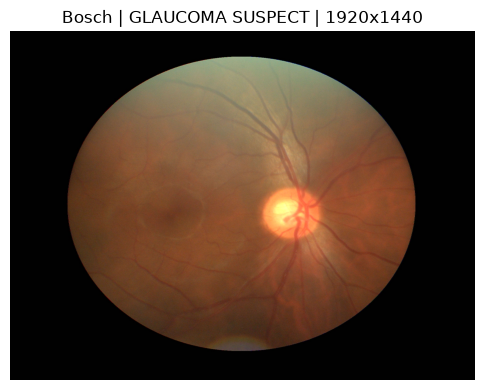

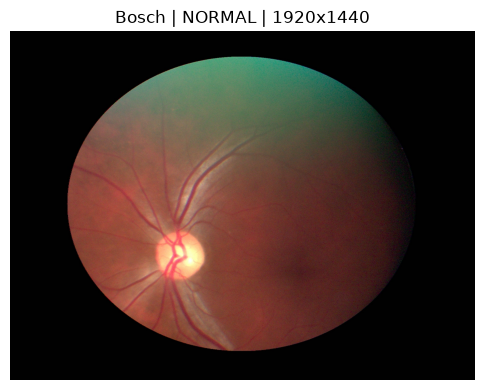

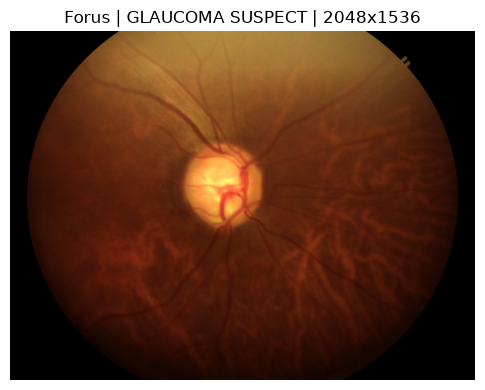

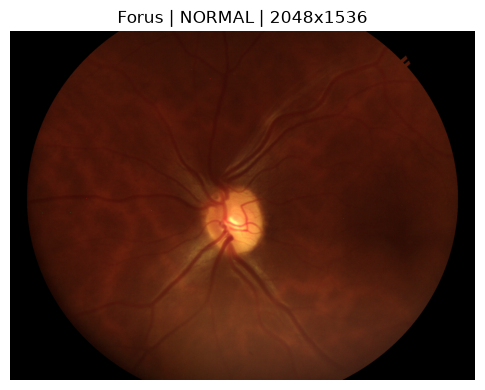

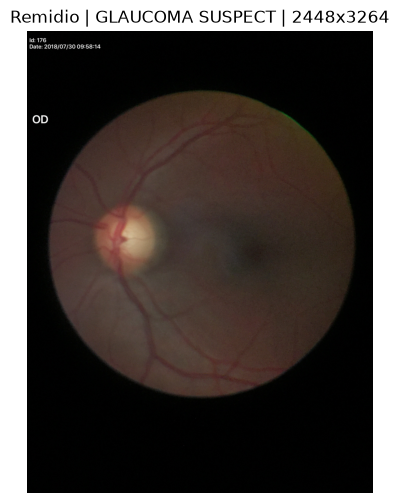

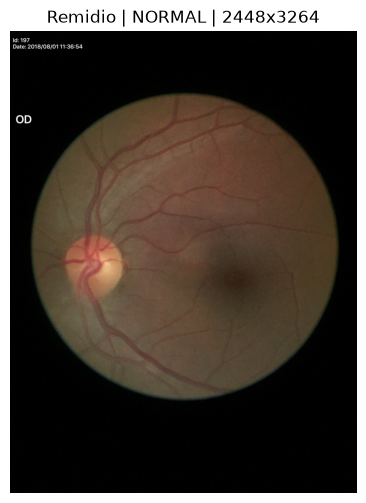

In [9]:
df_train = df[
    df["experimental_split"] == "train"
].copy()

muestras = (
    df_train
    .groupby(
        [
            "camera",
            "original_label"
        ],
        group_keys=False
    )
    .sample(
        n=1,
        random_state=42
    )
)

for _, fila in muestras.iterrows():
    ruta = resolver_ruta(
        fila["image_path"]
    )
    with Image.open(ruta) as img:
        plt.figure(
            figsize=(6, 6)
        )
        plt.imshow(img)
        plt.title(
            f"{fila['camera']} | "
            f"{fila['original_label']} | "
            f"{img.width}x{img.height}"
        )
        plt.axis("off")
        plt.show()

## 10. Revisión de resoluciones atípicas

Se identificó una imagen Remidio cuya resolución difiere de la resolución
predominante de 2448×3264. Se identifica el registro correspondiente para
verificar que pueda ser tratado correctamente por el pipeline general de
preprocesamiento.

In [10]:
remidio_atipicas = image_info[
    (image_info["camera"] == "Remidio")
    &
    (
        (image_info["width"] != 2448)
        |
        (image_info["height"] != 3264)
    )
].copy()
display(remidio_atipicas)

,image_key,camera,original_label,experimental_split,width,height,mode,format,error,aspect_ratio
1277,remidio::img_4439.jpg,Remidio,NORMAL,test,1969,2166,RGB,JPEG,None,0.909049


## 11. Detección automática del campo de visión retinal

Debido a las diferencias de encuadre entre los dispositivos Bosch, Forus y
Remidio, se evalúa un procedimiento automático para identificar el campo de
visión (FOV) retinal.

El objetivo es eliminar principalmente:

- fondo negro exterior;
- texto o marcas ubicadas fuera de la retina;
- diferencias de margen entre dispositivos.

La detección se desarrolla y valida exclusivamente con imágenes del
subconjunto Train. Las imágenes de Test no se utilizan para ajustar el
procedimiento.

El procedimiento no busca localizar únicamente el disco óptico, sino preservar
el campo retinal visible completo.

In [11]:
import cv2


## 12. Función para detectar el FOV

Se detecta el campo de visión (FOV) sobre la imagen binarizada mediante componentes conexas y se calcula su envolvente convexa (*convex hull*).

A diferencia de una máscara pixelar directa que puede presentar irregularidades o «mordidas» en los bordes oscuros de la periferia retiniana, el convex hull genera una envolvente suave y continua sobre la anatomía circular del globo ocular, rellenando el interior y preservando íntegra la periferia del campo de visión.

In [12]:
def detectar_fov(imagen_rgb, umbral=10):
    gris = cv2.cvtColor(
        imagen_rgb,
        cv2.COLOR_RGB2GRAY
    )
    _, mascara_inicial = cv2.threshold(
        gris,
        umbral,
        255,
        cv2.THRESH_BINARY
    )
    kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (15, 15)
    )
    mascara_limpia = cv2.morphologyEx(
        mascara_inicial,
        cv2.MORPH_CLOSE,
        kernel
    )
    # Buscar componentes conexas
    num_labels, labels, stats, _ = (
        cv2.connectedComponentsWithStats(
            mascara_limpia,
            connectivity=8
        )
    )
    if num_labels <= 1:
        return None, None
    # Ignorar el fondo (label 0)
    areas = stats[
        1:,
        cv2.CC_STAT_AREA
    ]
    mayor_componente = (
        1 + np.argmax(areas)
    )
    # Máscara de la componente retinal principal
    mascara_componente = (
        labels == mayor_componente
    ).astype(np.uint8) * 255
    # Buscar el contorno de esa componente
    contornos, _ = cv2.findContours(
        mascara_componente,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )
    if len(contornos) == 0:
        return None, None
    # Seleccionar el contorno más grande
    contorno_principal = max(
        contornos,
        key=cv2.contourArea
    )
    # Crear convex hull para suavizar y completar
    # la periferia del campo retinal
    hull = cv2.convexHull(
        contorno_principal
    )
    # Crear nueva máscara vacía
    mascara_fov = np.zeros_like(
        mascara_componente
    )
    # Rellenar el convex hull
    cv2.fillConvexPoly(
        mascara_fov,
        hull,
        255
    )
    # Bounding box calculado sobre el FOV continuo
    x, y, w, h = cv2.boundingRect(
        hull
    )
    return mascara_fov, (x, y, w, h)


## 13. Añadir un pequeño margen al recorte

No queremos que el bounding box quede demasiado ajustado y pueda cortar el límite de la retina.

Ese 0.02 significa apenas un 2 % de margen alrededor del FOV detectado.

In [13]:
def ampliar_bbox(
    bbox,
    image_width,
    image_height,
    margen=0.02
):
    x, y, w, h = bbox
    margen_x = int(w * margen)
    margen_y = int(h * margen)
    x1 = max(
        0,
        x - margen_x
    )
    y1 = max(
        0,
        y - margen_y
    )
    x2 = min(
        image_width,
        x + w + margen_x
    )
    y2 = min(
        image_height,
        y + h + margen_y
    )
    return x1, y1, x2, y2


## 14. Función de recorte

Todavía no hacemos resize. Primero queremos demostrar que el recorte funciona.

In [14]:
def recortar_fov(imagen_rgb):
    mascara, bbox = detectar_fov(
        imagen_rgb
    )
    if bbox is None:
        return imagen_rgb, None
    # Conservar únicamente la componente correspondiente al FOV.
    imagen_enmascarada = cv2.bitwise_and(
        imagen_rgb,
        imagen_rgb,
        mask=mascara
    )
    alto, ancho = imagen_rgb.shape[:2]
    x1, y1, x2, y2 = ampliar_bbox(
        bbox,
        image_width=ancho,
        image_height=alto,
        margen=0.02
    )
    recorte = imagen_enmascarada[
        y1:y2,
        x1:x2
    ]
    return recorte, (
        x1,
        y1,
        x2,
        y2
    )


## 15. Seleccionar muestras exclusivamente de Train

No reutilices la muestra anterior si fue obtenida de todo df.
Seleccionamos una imagen de cada cámara/clase a partir exclusivamente de Train.

Debes obtener seis casos:
- Bosch + NORMAL
- Bosch + GLAUCOMA SUSPECT
- Forus + NORMAL
- Forus + GLAUCOMA SUSPECT
- Remidio + NORMAL
- Remidio + GLAUCOMA SUSPECT

In [15]:
df_train = df[
    df["experimental_split"] == "train"
].copy()

muestras_fov = (
    df_train
    .groupby(
        [
            "camera",
            "original_label"
        ],
        group_keys=False
    )
    .sample(
        n=1,
        random_state=42
    )
)
display(
    muestras_fov[
        [
            "image_key",
            "camera",
            "original_label"
        ]
    ]
)


,image_key,camera,original_label
572,bosch::image107.jpg,Bosch,GLAUCOMA SUSPECT
35,bosch::image177.jpg,Bosch,NORMAL
680,forus::82.png,Forus,GLAUCOMA SUSPECT
80,forus::69.png,Forus,NORMAL
688,remidio::img_3360.jpg,Remidio,GLAUCOMA SUSPECT
108,remidio::img_3250.jpg,Remidio,NORMAL


## 16. Visualizar el FOV detectado

Ahora verificaremos qué área está seleccionando el algoritmo.
Aquí verás la imagen completa con un rectángulo verde alrededor de la retina para comprobar que cubra el FOV completo y no únicamente el disco óptico.

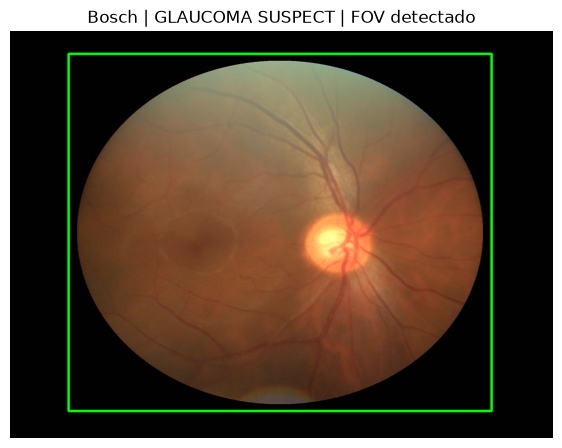

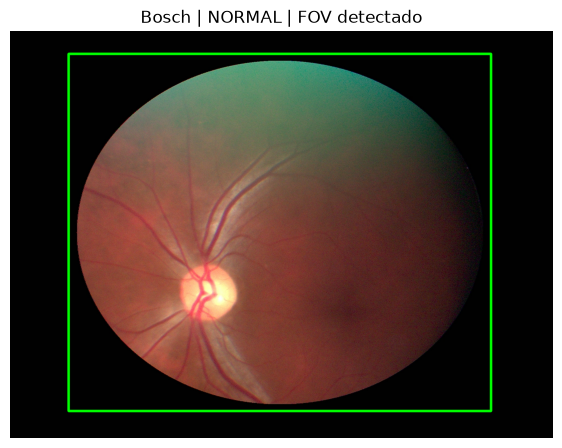

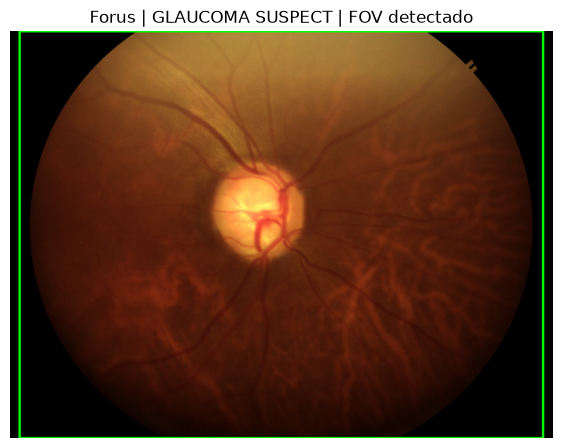

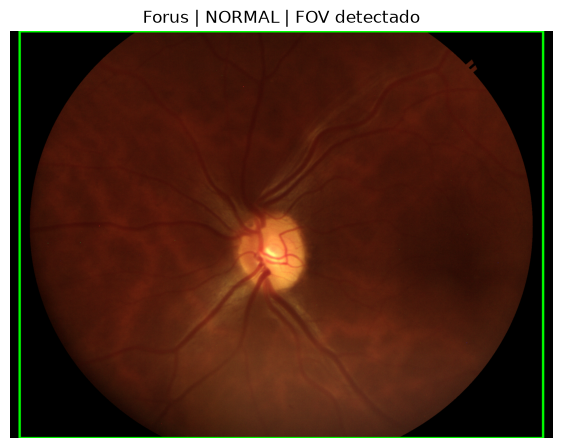

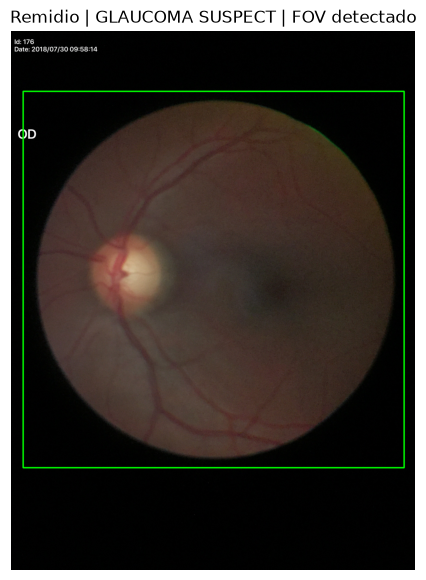

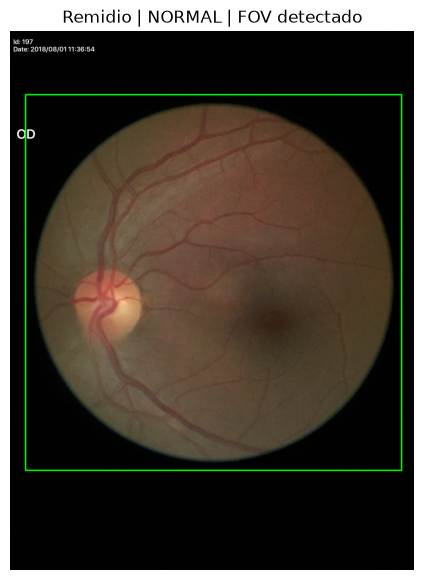

In [16]:
for _, fila in muestras_fov.iterrows():
    ruta = resolver_ruta(
        fila["image_path"]
    )
    with Image.open(ruta) as img:
        imagen_rgb = np.array(
            img.convert("RGB")
        )
    recorte, bbox = recortar_fov(
        imagen_rgb
    )
    if bbox is None:
        print(
            "No se pudo detectar FOV:",
            fila["image_key"]
        )
        continue
    x1, y1, x2, y2 = bbox
    imagen_bbox = imagen_rgb.copy()
    cv2.rectangle(
        imagen_bbox,
        (x1, y1),
        (x2, y2),
        (0, 255, 0),
        thickness=8
    )
    plt.figure(figsize=(7, 7))
    plt.imshow(imagen_bbox)
    plt.title(
        f"{fila['camera']} | "
        f"{fila['original_label']} | "
        "FOV detectado"
    )
    plt.axis("off")
    plt.show()


## 17. Visualizar el resultado del crop

Aquí tienes que fijarte en cuatro cosas:
- que no corte ninguna parte importante del círculo retinal;
- que desaparezca la mayoría del fondo negro;
- que en Remidio desaparezcan ID, Date, OD/OS;
- que el disco óptico siga completamente presente.

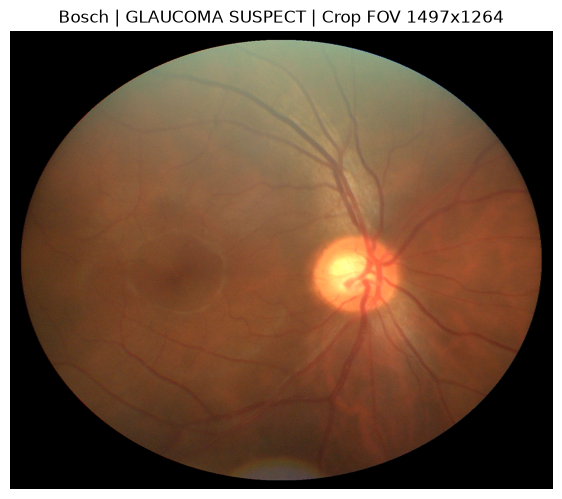

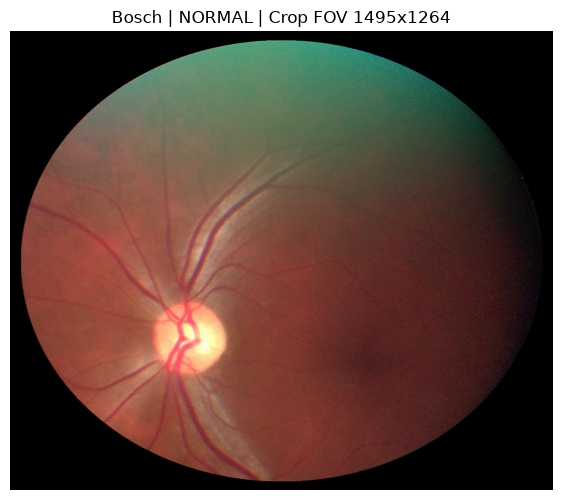

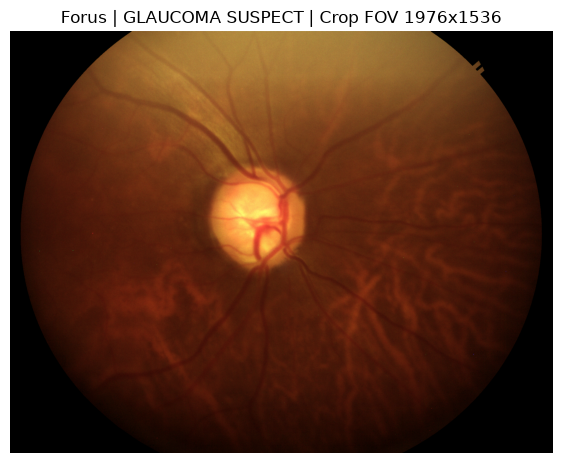

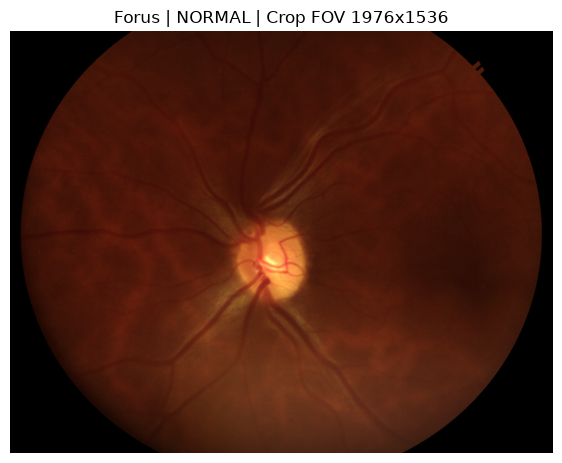

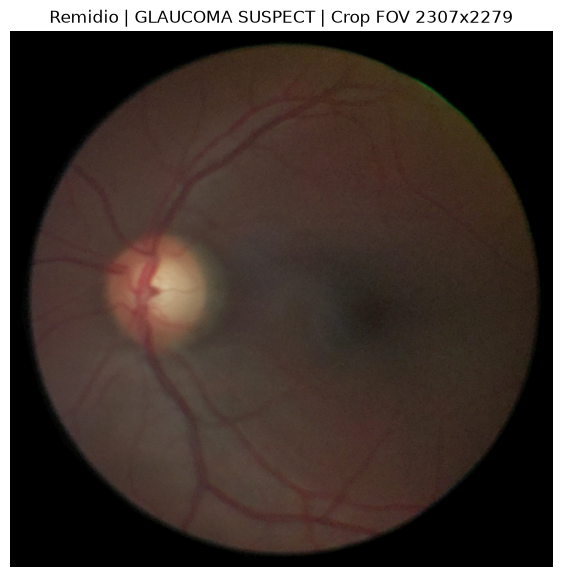

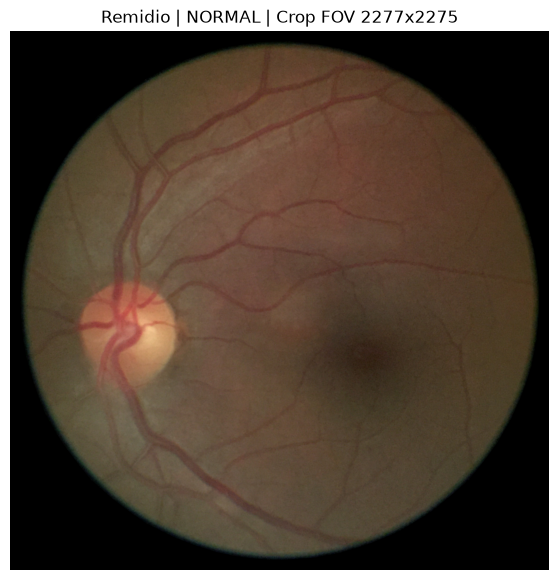

In [17]:
for _, fila in muestras_fov.iterrows():
    ruta = resolver_ruta(
        fila["image_path"]
    )
    with Image.open(ruta) as img:
        imagen_rgb = np.array(
            img.convert("RGB")
        )
    recorte, bbox = recortar_fov(
        imagen_rgb
    )
    plt.figure(figsize=(7, 7))
    plt.imshow(recorte)
    plt.title(
        f"{fila['camera']} | "
        f"{fila['original_label']} | "
        f"Crop FOV {recorte.shape[1]}x{recorte.shape[0]}"
    )
    plt.axis("off")
    plt.show()


## 18. Registrar cuánto estamos recortando

Además de mirar seis imágenes, se calcula una medida cuantitativa procesando las 807 imágenes de Train.

In [18]:
resultados_fov = []
for _, fila in df_train.iterrows():
    ruta = resolver_ruta(
        fila["image_path"]
    )
    with Image.open(ruta) as img:
        imagen_rgb = np.array(
            img.convert("RGB")
        )
    recorte, bbox = recortar_fov(
        imagen_rgb
    )
    alto_original, ancho_original = (
        imagen_rgb.shape[:2]
    )
    if bbox is None:
        resultados_fov.append({
            "image_key": fila["image_key"],
            "camera": fila["camera"],
            "deteccion_ok": False,
            "original_width": ancho_original,
            "original_height": alto_original,
            "crop_width": None,
            "crop_height": None,
            "retained_area_pct": None
        })
        continue
    alto_crop, ancho_crop = (
        recorte.shape[:2]
    )
    porcentaje_area = (
        ancho_crop * alto_crop
        /
        (
            ancho_original
            * alto_original
        )
        * 100
    )
    resultados_fov.append({
        "image_key": fila["image_key"],
        "camera": fila["camera"],
        "deteccion_ok": True,
        "original_width": ancho_original,
        "original_height": alto_original,
        "crop_width": ancho_crop,
        "crop_height": alto_crop,
        "retained_area_pct": porcentaje_area
    })

fov_info = pd.DataFrame(
    resultados_fov
)
print(
    "Train analizadas:",
    len(fov_info)
)
print(
    "Detecciones fallidas:",
    (~fov_info["deteccion_ok"]).sum()
)


Train analizadas: 807
Detecciones fallidas: 0


## 19. Resumen por cámara

Esto nos permitirá ver numéricamente cuánto fondo estamos quitando en Bosch, Forus y Remidio.

In [19]:
resumen_fov = (
    fov_info[
        fov_info["deteccion_ok"]
    ]
    .groupby("camera")[
        "retained_area_pct"
    ]
    .agg(
        [
            "min",
            "mean",
            "median",
            "max"
        ]
    )
    .round(2)
)
display(resumen_fov)


,min,mean,median,max
camera,,,,
Bosch,67.71,68.38,68.40,68.49
Forus,96.29,96.48,96.48,96.48
Remidio,52.57,65.15,64.40,77.36


## 20. Inspección de casos extremos de detección del FOV

Aunque el procedimiento detectó un FOV en todas las imágenes de Train, se
revisan manualmente los casos con menor y mayor porcentaje de área retenida
por dispositivo.

Esta comprobación permite identificar posibles recortes excesivos o
detecciones demasiado amplias antes de congelar el pipeline.

In [20]:
casos_extremos = []
for camara in fov_info["camera"].unique():
    subset = fov_info[
        (fov_info["camera"] == camara)
        &
        (fov_info["deteccion_ok"])
    ]
    idx_min = subset[
        "retained_area_pct"
    ].idxmin()
    idx_max = subset[
        "retained_area_pct"
    ].idxmax()
    casos_extremos.append(
        fov_info.loc[idx_min]
    )
    casos_extremos.append(
        fov_info.loc[idx_max]
    )
casos_extremos = pd.DataFrame(
    casos_extremos
)
display(
    casos_extremos[
        [
            "image_key",
            "camera",
            "original_width",
            "original_height",
            "crop_width",
            "crop_height",
            "retained_area_pct"
        ]
    ]
)


,image_key,camera,original_width,original_height,crop_width,crop_height,retained_area_pct
478,remidio::img_3560.jpg,Remidio,2448,3264,2225,1888,52.573930
724,remidio::img_3650.jpg,Remidio,2448,3264,2448,2525,77.359069
79,bosch::image164.jpg,Bosch,1920,1440,1481,1264,67.707755
226,bosch::image131.jpg,Bosch,1920,1440,1497,1265,68.493381
651,forus::53.png,Forus,2048,1536,1972,1536,96.289062
17,forus::63.png,Forus,2048,1536,1976,1536,96.484375


## 21. Visualizar esos seis extremos

Se recuperan las rutas y etiquetas originales a partir de `image_key` y se
visualizan los recortes resultantes.

El objetivo es revisar los casos con menor y mayor porcentaje de área retenida
de cada dispositivo, prestando especial atención al caso Remidio con menor área
retenida. Se verifica que la reducción corresponda principalmente a la
eliminación de fondo externo y que el campo retinal permanezca preservado.

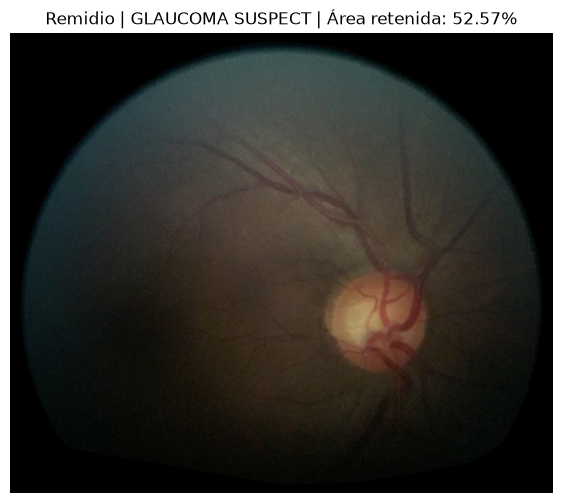

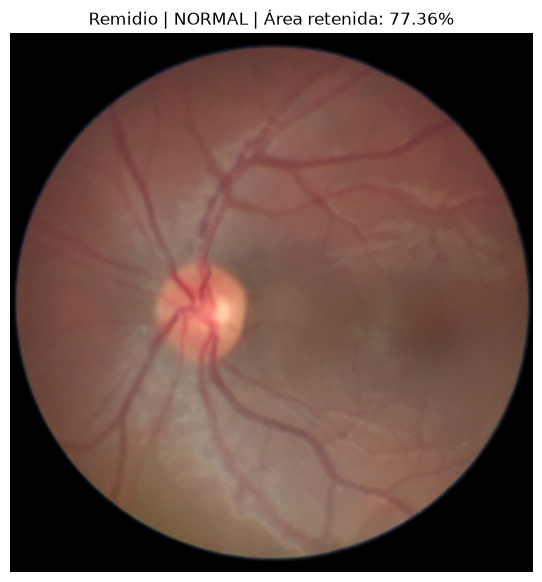

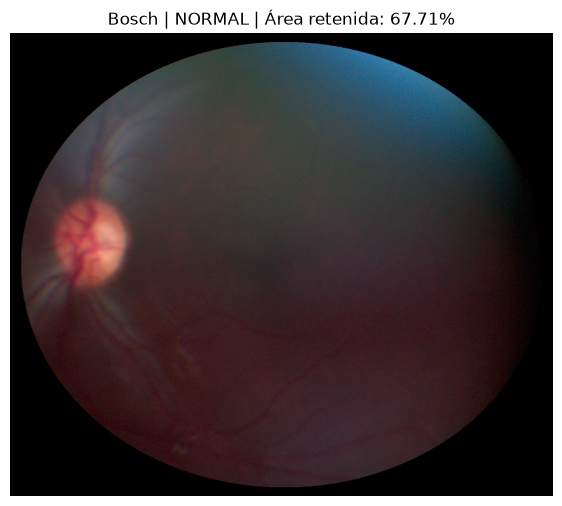

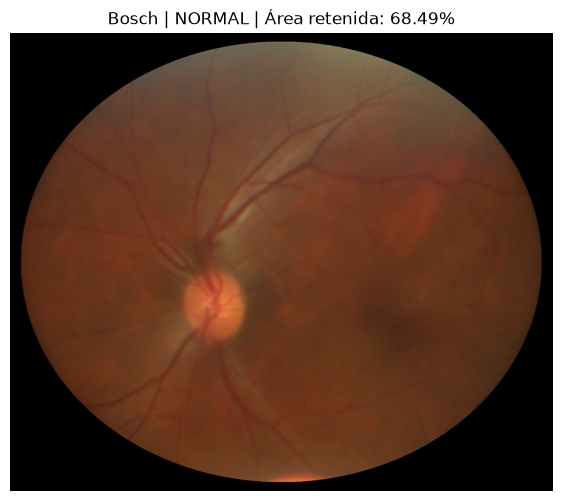

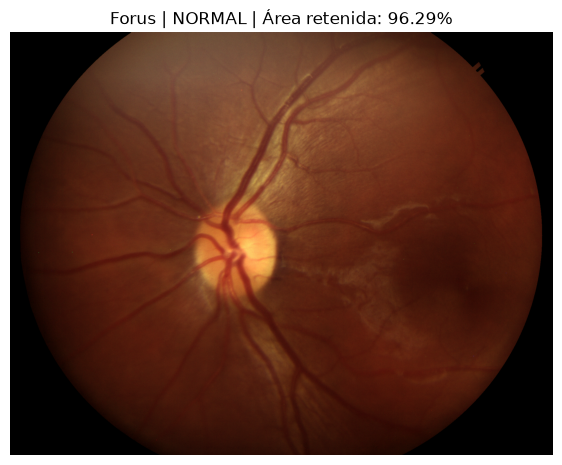

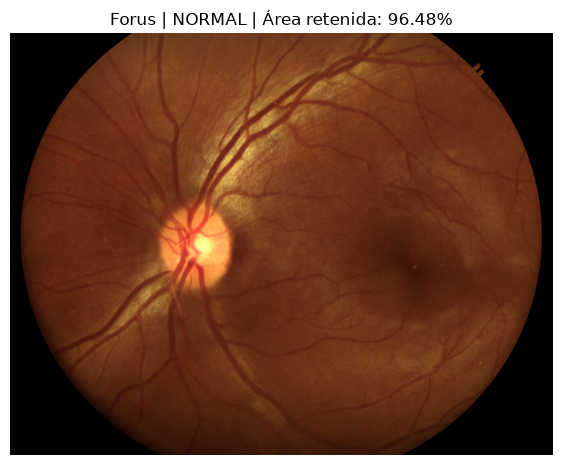

In [21]:
casos_extremos = casos_extremos.merge(
    df_train[
        [
            "image_key",
            "image_path",
            "original_label"
        ]
    ],
    on="image_key",
    how="left"
)

for _, fila in casos_extremos.iterrows():
    ruta = resolver_ruta(
        fila["image_path"]
    )
    with Image.open(ruta) as img:
        imagen_rgb = np.array(
            img.convert("RGB")
        )
    recorte, bbox = recortar_fov(
        imagen_rgb
    )
    plt.figure(figsize=(7, 7))
    plt.imshow(recorte)
    plt.title(
        f"{fila['camera']} | "
        f"{fila['original_label']} | "
        f"Área retenida: "
        f"{fila['retained_area_pct']:.2f}%"
    )
    plt.axis("off")
    plt.show()


### Precisión metodológica sobre la imagen Remidio atípica

La imagen identificada con resolución de **1969 × 2166** (`remidio::img_4439.jpg`) no se elimina ni se traslada a Train: permanece intacta en el subconjunto **Test**.

Cuando el pipeline de preprocesamiento quede congelado, el algoritmo operará sobre ella de manera homogénea e independiente de su resolución original:

$$\text{imagen variable} \longrightarrow \text{detectar FOV} \longrightarrow \text{crop} \longrightarrow \text{padding} \longrightarrow 384 \times 384$$

De esta manera, el pipeline de producción no depende de que todas las imágenes compartan de forma fija la dimensión de 2448 × 3264.

# Conclusiones de la exploración visual

La exploración permitió verificar las características técnicas y visuales de las
1,345 retinografías del dataset Chákṣu.

Se comprobó que:

- Todas las imágenes pueden ser decodificadas correctamente.
- Las 1,345 imágenes se encuentran en formato RGB.
- Existen diferencias de resolución, orientación y encuadre entre los
  dispositivos Bosch, Forus y Remidio.
- Las imágenes contienen diferentes cantidades de fondo negro alrededor del
  campo retinal.
- Algunas imágenes Remidio contienen texto y marcas fuera del campo de visión.
- Se desarrolló un procedimiento automático de detección del FOV basado en
  threshold, componente conexa principal y convex hull.
- El procedimiento fue evaluado exclusivamente sobre las 807 imágenes de Train.
- Se procesaron correctamente las 807 imágenes de Train sin detecciones fallidas.
- La revisión visual de los casos extremos no evidenció recortes problemáticos
  del campo retinal en las muestras inspeccionadas, mientras que el procedimiento
  automático logró procesar las 807 imágenes de Train sin detecciones fallidas.

A partir de estos resultados se adopta el recorte automático del campo de visión
como primera etapa del pipeline de preprocesamiento.

Las decisiones posteriores de transformación se realizarán preservando la
geometría retinal y sin utilizar el subconjunto Test para ajustar el pipeline.